In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.mixture import GaussianMixture
from statsmodels.stats.multitest import multipletests
import scipy
from scipy.stats import f_oneway
from scipy import stats
import re
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)
greens = sns.blend_palette(['#c8e9c1', '#75c477','#238b45'  ], as_cmap = True)
purples = sns.blend_palette(['#dadaeb', '#9e9bc8','#6a51a3' ], as_cmap = True)
oranges = sns.blend_palette(['#fdd1a3', '#fd8e3d','#d94801' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'


In [ ]:
#First new bed files have to be created that are used of counting on all annotated TSS per gene
gtffile= pd.read_csv('input/annotations_cleaned.gtf', index_col=None, skiprows=5, header=None, low_memory=False, delimiter="\t")
gtffile[:5]

In [ ]:
gtffile.columns=("chr","database","type","start","stop","unkown","strand","CDS","details")
genes2=gtffile[gtffile['type']=='gene'].copy()
step1=genes2["details"].str.split(';', n=0, expand=True)
step2=step1[2].str.split('"', n=0, expand=True)
genes2["genename"]=step2[1]
step3=step1[0].str.split('"', n=0, expand=True)
genes2["geneID"]=step3[1]
step5=step1[4].str.split('"',n= 0, expand=True)
genes2["biotype"]=step5[1]


genes2=genes2[genes2['genename']!='ensembl']


In [ ]:
#to get main isoforms
genes2_plus=genes2[genes2['strand']=='+'].sort_values(by='start',ascending=True)
genes2_minus=genes2[genes2['strand']=='-'].sort_values(by='start', ascending=False)
plus2=genes2_plus.drop_duplicates(subset = ['genename'], keep = 'first').reset_index(drop = True)
minus2=genes2_minus.drop_duplicates(subset = ['genename'], keep = 'first').reset_index(drop = True)


In [ ]:
gtffile.columns=("chr","database","type","start","stop","unkown","strand","CDS","details")
genes=gtffile[gtffile['type']=='transcript'].copy()
step1=genes["details"].str.split(';', n=0, expand=True)
step2=step1[4].str.split('"', n=0, expand=True)
genes["genename"]=step2[1]
step3=step1[0].str.split('"', n=0, expand=True)
genes["geneID"]=step3[1]
step5=step1[6].str.split('"', n=0, expand=True)
genes["biotype"]=step5[1]

step7=step1[3].str.split('"', n=0, expand=True)
genes["transcript_number"]=step7[1]
genes=genes[genes['genename']!='ensembl']

genes[:5]

In [ ]:
#manully add and remove TSS from manuel IGV inspection

genes=pd.concat([genes,pd.DataFrame({"chr":5,"database":'new','type':'transcript','start':8712500,"stop":8715000,'unkown':'.','strand':'+','details':'','genename':'Abcb1a','geneID':'ENSMUSG00000040584','biotype':'protein_coding','transcript_number':'5'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":9,"database":'new','type':'transcript','start':67633263,"stop":67633263,'unkown':'.','strand':'-','details':'','genename':'Tln2','geneID':'ENSMUSG00000052698','biotype':'protein_coding','transcript_number':'1'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":9,"database":'new','type':'transcript','start':32032242,"stop":32032242,'unkown':'.','strand':'+','details':'','genename':'Arhgap32','geneID':'ENSMUSG00000041444','biotype':'protein_coding','transcript_number':'1'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":12,"database":'new','type':'transcript','start':117155115,"stop":117155115,'unkown':'.','strand':'+','details':'','genename':'Ptprn2','geneID':'ENSMUSG00000056553','biotype':'protein_coding','transcript_number':'1'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":'X',"database":'new','type':'transcript','start':151169972,"stop":151169972,'unkown':'.','strand':'+','details':'','genename':'Wnk3','geneID':'ENSMUSG00000041245','biotype':'protein_coding','transcript_number':'1'}, index=[0])])


genes_to_remove={'Gm49797','Ttn','Mirg','Gucy1b2'}
genes=genes[~genes['genename'].isin(genes_to_remove)]



In [ ]:
genes=genes[genes['biotype'].isin({'protein_coding','lncRNA'})]

In [ ]:
#to get main starting isoforms
genes_plus=genes[genes['strand']=='+'].sort_values(by='start',ascending=True)
genes_minus=genes[genes['strand']=='-'].sort_values(by='start', ascending=False)
plus=genes_plus.sort_values(by='transcript_number').drop_duplicates(subset = ['genename', 'start'], keep = 'first').reset_index(drop = True)
minus=genes_minus.sort_values(by='transcript_number').drop_duplicates(subset = ['genename', 'stop'], keep = 'first').reset_index(drop = True)


In [ ]:

def select_spaced(df, gene_col, pos_col, gap=10_000, ascending=True):
   
    # Sort within groups
    df_sorted = df.sort_values([gene_col, pos_col], ascending=[True, ascending]).copy()

    selected_indices = []
    # Iterate per gene
    for g, sub in df_sorted.groupby(gene_col, sort=False):

        positions = sub[pos_col].to_numpy()
        idx = sub.index.to_numpy()

        # always keep the first, then apply gap criterion vs last kept
        keep = []
        last_pos = None
        for i, p in zip(idx, positions):
            if last_pos is None:
                keep.append(i)
                last_pos = p
            else:
                if ascending:
                    if (p - last_pos) > gap:
                        keep.append(i)
                        last_pos = p
                else:
                    if (last_pos - p) > gap:
                        keep.append(i)
                        last_pos = p
        selected_indices.extend(keep)

    out = df.loc[selected_indices].copy()
    out = out.sort_values([gene_col, pos_col], ascending=[True, ascending])

    # Assign group-local ranks for genename2
    out['genename2'] = (
        out[gene_col] + ':' +
        (out.groupby(gene_col).cumcount() + 1).astype(str)
    )
    return out

# Apply to your dataframes
plus = select_spaced(plus, gene_col='genename', pos_col='start', gap=10_000, ascending=True)
minus = select_spaced(minus, gene_col='genename', pos_col='stop',  gap=10_000, ascending=False)


In [ ]:

plus = plus.copy()
plus['prom_type'] = 'other'

# Map main annotated start per gene
main_start = plus2.groupby('genename')['start'].first()  

# Vectorized distance to main annotated start
plus['dist_main'] = (plus['start'] - plus['genename'].map(main_start)).abs()

# Mark the closest row in each gene as 'main_an'
idx_min = plus.groupby('genename')['dist_main'].idxmin()
plus.loc[idx_min, 'prom_type'] = 'main_an'

# Count promoters per gene 
plus['prom_num_an'] = plus.groupby('genename')['stop'].transform('size')


In [ ]:

minus = minus.copy() 
minus['prom_type'] = 'other'

# Map the main annotated stop per gene
main_stop = minus2.groupby('genename')['stop'].last()  

# Vectorized distance to main annotated stop
minus['dist_main'] = (minus['stop'] - minus['genename'].map(main_stop)).abs()

# Mark the closest row in each gene as 'main_an'
idx_min = minus.groupby('genename')['dist_main'].idxmin()
minus.loc[idx_min, 'prom_type'] = 'main_an'

# Count promoters per gene 
minus['prom_num_an'] = minus.groupby('genename')['start'].transform('size')


In [ ]:
#identify and remove promotors overlaqpping gene end
plus2copy=plus2[['genename','stop']].copy()
plus2copy.columns=['genename','geneend']
plus=plus.merge(plus2copy, how='left', left_on='genename', right_on='genename')
plus['enddist']=plus['geneend']-plus['start']

In [ ]:
promstoremveplus=plus.loc[((plus['enddist']<7500)&(plus['prom_type']=='other')),'genename2']

In [ ]:
minus2copy=minus2[['genename','start']].copy()
minus2copy.columns=['genename','geneend']
minus=minus.merge(minus2copy, how='left', left_on='genename', right_on='genename')
minus['enddist']=minus['stop']-minus['geneend']

In [ ]:
promstoremveminus=minus.loc[((minus['enddist']<7500)&(minus['prom_type']=='other')),'genename2']

In [ ]:
promstoremve=pd.concat([promstoremveplus,promstoremveminus])

In [ ]:
plus=plus[~plus['genename2'].isin(promstoremveplus)]
minus=minus[~minus['genename2'].isin(promstoremveminus)]


In [ ]:
distup=2500
distdown=7500

#for chrom
plusstart=plus["start"]-distup
plusstop=plus["start"]+distdown
plusfinal=pd.DataFrame({"chr":plus["chr"],"start":plusstart,"stop":plusstop,"name":plus["genename2"],'biotype':plus['biotype']})
minusstart=minus["stop"]-distdown
minusstop=minus["stop"]+distup
minusfinal=pd.DataFrame({"chr":minus["chr"],"start":minusstart,"stop":minusstop,"name":minus["genename2"],'biotype':minus['biotype']})
final=pd.concat([plusfinal,minusfinal])

plusfinal2=pd.DataFrame({"chr":plus["chr"],"start":plusstart,"stop":plusstop,"name":plus["genename2"],'biotype':plus['biotype'],'gene':plus['genename'],'prom_type':plus['prom_type'],'prom_num_an':plus['prom_num_an']})

minusfinal2=pd.DataFrame({"chr":minus["chr"],"start":minusstart,"stop":minusstop,"name":minus["genename2"],'biotype':minus['biotype'],'gene':minus['genename'],'prom_type':minus['prom_type'],'prom_num_an':minus['prom_num_an']})
final2=pd.concat([plusfinal2,minusfinal2])



final.loc[final['start']<0,'start']=0
final.loc[final['stop']<0,'stop']=0

final2.loc[final2['start']<0,'start']=0
final2.loc[final2['stop']<0,'stop']=0

In [ ]:
final.to_csv('output/mouse_allex_TRiso_starts_10kb_v4.bed',header=None, index=None, sep="\t")
final2.to_csv('output/mouse_allex_TRiso_starts_10kb_v4_detailed.bed',header=None, index=None, sep="\t")

In [ ]:
#for RNA
distup=10000
distdown=10000
plusup=plus["start"]-distup
plusdown=plus["start"]+distdown
plusfinalup=pd.DataFrame({"chr":plus["chr"],"start":plusup,"stop":plus["start"],"name":(plus["genename2"]+':'+'up'),'score':0,'strand':'+','biotype':plus['biotype']})
plusfinaldown=pd.DataFrame({"chr":plus["chr"],"start":plus["start"],"stop":plusdown,"name":(plus["genename2"]+':'+'down'),'score':0,'strand':'+','biotype':plus['biotype']})

minusup=minus["stop"]+distup
minusdown=minus["stop"]-distdown
minusfinalup=pd.DataFrame({"chr":minus["chr"],"start":minus["stop"],"stop":minusup,"name":(minus["genename2"]+':'+'up'),'score':0,'strand':'-','biotype':minus['biotype']})
minusfinaldown=pd.DataFrame({"chr":minus["chr"],"start":minusdown,"stop":minus["stop"],"name":(minus["genename2"]+':'+'down'),'score':0,'strand':'-','biotype':minus['biotype']})

final3=pd.concat([plusfinalup,plusfinaldown,minusfinalup,minusfinaldown])

final3.loc[final3['start']<0,'start']=0
final3.loc[final3['stop']<0,'stop']=0

In [ ]:
final3.to_csv('output/mouse_allex_TRiso_starts_10kb_UpDo_v4.bed',header=None, index=None, sep="\t")

In [ ]:
#map reads using bamCountRegions.py input.bam -t 1 -regions countregions.bed -o output.csv -s output_total.csv

Start single cell count data analysis

In [ ]:
#load sc count data on different regions
# load H3K4me3 data
K4scdata=pd.read_csv('input/H3K4me3_Tiso_K4sel_10kb_counts_v4.csv', sep=',',low_memory=True)
K4scdata.index=K4scdata['Unnamed: 0']
K4scdata=K4scdata.drop(columns=['Unnamed: 0'])
for col in K4scdata.columns:
    if pd.api.types.is_integer_dtype(K4scdata[col]):
        K4scdata[col] = pd.to_numeric(K4scdata[col], downcast='integer')

# load H3K27me3 data
K27scdata=pd.read_csv('input/H3K27me3_Tiso_K4sel_10kb_counts_v4.csv', sep=',',low_memory=True)
K27scdata.index=K27scdata['Unnamed: 0']
K27scdata=K27scdata.drop(columns=['Unnamed: 0'])
for col in K27scdata.columns:
    if pd.api.types.is_integer_dtype(K27scdata[col]):
        K27scdata[col] = pd.to_numeric(K27scdata[col], downcast='integer')

#load RNA data
chunks = pd.read_csv('input/RNA_Tiso_K4sel_10kbupdown_counts_v4.csv', sep=',', chunksize=20_000)
parts = []
for chunk in chunks:
    chunk.index=chunk['Unnamed: 0']
    chunk=chunk.drop(columns=['Unnamed: 0'])
    for col in chunk.columns:
        if pd.api.types.is_integer_dtype(chunk[col]):
            chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
    parts.append(chunk)

RNAscdataupdown = pd.concat(parts)


In [ ]:

# keep only downstream RNA counts and adjust index for data integration
RNAscdatadown=RNAscdataupdown.T.copy()
del RNAscdataupdown
RNAscdatadown['name']=RNAscdatadown.index
tmp=pd.Series(RNAscdatadown['name']).str.split(':', n=0, expand=True)
tmp.index=RNAscdatadown.index
RNAscdatadown['name2']=tmp[0]+':'+tmp[1]
RNAscdatadown['dir']=tmp[2]
RNAscdatadown=RNAscdatadown[RNAscdatadown['dir']=='down']
RNAscdatadown.index=RNAscdatadown['name2']
RNAscdatadown=RNAscdatadown.drop(columns=['name','name2', 'dir'])

#for annotation
adata = sc.read_h5ad('input/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')

In [ ]:
#Create downsampled celllist for lineage pseudobulk. created csv can be used with bamExtractSamples.py from SCMO

cellnumber=1400
PBselection=pd.DataFrame(columns=['name','lineage'])
PBselection['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['celltype_general']=='mESCs'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselection['lineage']='ESC'

PBselectiontmp=pd.DataFrame(columns=['name','lineage'])
PBselectiontmp['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Ectoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselectiontmp['lineage']='ECT'
PBselection=pd.concat([PBselection,PBselectiontmp])

PBselectiontmp=pd.DataFrame(columns=['name','lineage'])
PBselectiontmp['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Endoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselectiontmp['lineage']='END'
PBselection=pd.concat([PBselection,PBselectiontmp])

PBselectiontmp=pd.DataFrame(columns=['name','lineage'])
PBselectiontmp['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Mesoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselectiontmp['lineage']='MES'
PBselection=pd.concat([PBselection,PBselectiontmp])

PBselection.to_csv('Cells_forPB_1400cells.csv',header=False, index=False, sep="\t")

In [ ]:
def tss_glm_prom_K4(b_df, value, layer, pc):

    result_total=pd.DataFrame()
    

    # Subset the data once
    test_data = b_df.pivot(index=layer,columns='Linrep',values=value).replace(np.nan, 0)
    ano_data = b_df.pivot(index=layer,columns='Linrep',values='Lin').iloc[0]
    lin=b_df.pivot(index=layer,columns='Linrep',values='Lin').iloc[0].unique()

    # Perform t-tests in a vectorized way for each gene


    for i in test_data.index:  # Loop over genes by index
        data = pd.DataFrame({
            'counts': test_data.loc[i]+pc,
            'group': ano_data
        })
        if (data['counts'].nunique() != 1):
            data['counts'] += np.random.normal(0, 0.1, size=data.shape[0])
            model = smf.glm(formula="counts ~ group", data=data, family=sm.families.Poisson()).fit()
        
            # Handle cases where t-test returns invalid p-values
            results = pd.DataFrame({
                'Lin':lin,
                'p':model.pvalues,
                'fold':(model.params)/ np.log(2),
                'name':i
                })
        if (data['counts'].nunique() == 1):
            results = pd.DataFrame({
                'Lin':lin,
                'p':1,
                'fold':0,
                'name':i
                })

        result_total=pd.concat([result_total, results], ignore_index=True)
    # Apply multiple testing correction (Benjamini-Hochberg FDR)
    result_total['p'] = result_total['p'].replace(np.nan, 1)
    result_total['p'] = result_total['p'].replace(0, 1e-10)
    result_total['p'] = result_total['p'].replace(np.inf, 1e-10)

    result_total['p_cor'] = multipletests(result_total['p'], method='fdr_bh')[1]

    # Combine results into a DataFrame
    
    result_total['-log10p']=-np.log10(result_total['p_cor'])
    return result_total[result_total['Lin']!='B'][['name','Lin','fold','-log10p']]

In [ ]:
def tss_glm_RNA(b_df, value, layer, pc):

    result_total=pd.DataFrame()
    

    # Subset the data once
    test_data = b_df.pivot_table(index=layer,columns='Linrep',values=value, aggfunc='first').replace(np.nan, 0)
    ano_data = b_df.pivot_table(index=layer,columns='Linrep',values='Lin', aggfunc='first').iloc[0]
    lin=b_df.pivot_table(index=layer,columns='Linrep',values='Lin', aggfunc='first').iloc[0].unique()

    # Perform t-tests in a vectorized way for each gene


    for i in test_data.index:  # Loop over genes by index
        data = pd.DataFrame({
            'counts': test_data.loc[i]+pc,
            'group': ano_data
        })
        if (data['counts'].nunique() != 1):
            data['counts'] += np.random.normal(0, 0.1, size=data.shape[0])
            model = smf.glm(formula="counts ~ group", data=data, family=sm.families.Poisson()).fit()
        
            # Handle cases where t-test returns invalid p-values
            results = pd.DataFrame({
                'Lin':lin,
                'p':model.pvalues,
                'fold':(model.params)/ np.log(2),
                'name':i
                })
        if (data['counts'].nunique() == 1):
            results = pd.DataFrame({
                'Lin':lin,
                'p':1,
                'fold':0,
                'name':i
                })

        result_total=pd.concat([result_total, results], ignore_index=True)
    # Apply multiple testing correction (Benjamini-Hochberg FDR)
    result_total['p'] = result_total['p'].replace(np.nan, 1)
    result_total['p'] = result_total['p'].replace(0, 1e-10)
    result_total['p'] = result_total['p'].replace(np.inf, 1e-10)

    result_total['p_cor'] = multipletests(result_total['p'], method='fdr_bh')[1]

    # Combine results into a DataFrame
    
    result_total['-log10p']=-np.log10(result_total['p_cor'])
    return result_total[result_total['Lin']!='B'][['name','Lin','fold','-log10p']]

In [ ]:
def tss_glm_prom_RNA_dif(b_df, value, pc):
    result_list = []  # Use a list to store results instead of concatenating DataFrames

    # Preprocess aggregated data once
    agg_functions = {value: 'mean'}
    grouped_data = b_df.groupby(['gene', 'Lin', 'rep', 'Linrep']).aggregate(agg_functions).reset_index()
    grouped_data['prom'] = '0'

    for gene, tmp in b_df.groupby('gene'):
        tmp_grouped = grouped_data[grouped_data['gene'] == gene]

        data = pd.DataFrame({
            'sample': pd.concat([tmp['Linrep'], tmp_grouped['Linrep']]),
            'condition': pd.concat([tmp['Lin'], tmp_grouped['Lin']]),
            'exon': pd.concat([tmp['prom'], tmp_grouped['prom']]),
            'count': pd.concat([tmp[value], tmp_grouped[value]]) + pc
        })

        if (data['count'].nunique() != 1):
            # Fit GLM model
            data['count'] += np.random.normal(0, 0.1, size=data.shape[0])
            model = smf.glm(
                formula="count ~ condition + exon + condition:exon",
                data=data,
                family=sm.families.Poisson()
            ).fit()
    
            # Extract coefficients and p-values
            df = pd.concat([(model.params) / np.log(2), model.pvalues], axis=1).reset_index()
            df.columns = ['index', 'fold', 'p']
            filtered_df = df[df['index'].str.contains("condition") & df['index'].str.contains("exon")]
    
            # Extract values in square brackets
            filtered_df['condition_exon_values'] = filtered_df['index'].apply(
                lambda x: re.findall(r'T\.(\w+)', x)
            )
    
            # Split into condition and exon
            filtered_df[['condition', 'exon']] = pd.DataFrame(
                filtered_df['condition_exon_values'].tolist(), index=filtered_df.index
            )
    
            # Prepare results
            filtered_df = filtered_df[['fold', 'p', 'condition', 'exon']]
            filtered_df.columns = ['fold', 'p', 'Lin', 'prom']
            filtered_df['gene'] = gene
            result_list.append(filtered_df)

        if (data['count'].nunique() == 1):
            filtered_df = pd.DataFrame({'fold':0, 'p':1,'Lin':tmp[tmp['rep']==1]['Lin'],'prom':tmp[tmp['rep']==1]['prom'],'gene':gene})
            result_list.append(filtered_df)

    # Concatenate all results at once
    result_total = pd.concat(result_list, ignore_index=True)

    # Apply multiple testing correction
    result_total['p'] = result_total['p'].replace([np.nan, 0, np.inf], 1e-10)
    result_total['p_cor'] = multipletests(result_total['p'], method='fdr_bh')[1]

    # Add -log10(p) column
    result_total['-log10p'] = -np.log10(result_total['p_cor'])

    return result_total[result_total['Lin']!='B'][['gene','Lin','prom','fold','-log10p']]

In [ ]:
#generate 5 none overlapping lineage pseudobulks for analysis
maxCells=len(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Endoderm'))].obs['cellname'])

rep=5

cellnumber=round(maxCells/rep)-1

cells0=pd.DataFrame(columns=range(1,rep+1))
cells1=pd.DataFrame(columns=range(1,rep+1))
cells2=pd.DataFrame(columns=range(1,rep+1))
cells3=pd.DataFrame(columns=range(1,rep+1))
cells4=pd.DataFrame(columns=range(1,rep+1))
cells5=pd.DataFrame(columns=range(1,rep+1))
cells6=pd.DataFrame(columns=range(1,rep+1))
cells7=pd.DataFrame(columns=range(1,rep+1))
cells8=pd.DataFrame(columns=range(1,rep+1))
cells9=pd.DataFrame(columns=range(1,rep+1))
cells10=pd.DataFrame(columns=range(1,rep+1))
cells11=pd.DataFrame(columns=range(1,rep+1))

used=pd.DataFrame(columns=[0])
for i in range(1,rep+1):
    cells0[i]=(adata[((adata.obs['mark']=='H3K4me3')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells1[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['celltype_general']=='mESCs')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells3[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Ectoderm')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells4[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Endoderm')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells5[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Mesoderm')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    
    cells11[i]=(adata[((adata.obs['mark']=='H3K27me3')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells6[i]=(adata[((adata.obs['mark']=='H3K27me3')&(adata.obs['celltype_general']=='mESCs')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells8[i]=(adata[((adata.obs['mark']=='H3K27me3')&(adata.obs['lineage']=='Ectoderm')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells9[i]=(adata[((adata.obs['mark']=='H3K27me3')&(adata.obs['lineage']=='Endoderm')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells10[i]=(adata[((adata.obs['mark']=='H3K27me3')&(adata.obs['lineage']=='Mesoderm')&~(adata.obs['cellname'].isin(used[0])))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    used=pd.concat([used,cells1[i],cells2[i],cells3[i],cells4[i],cells5[i],cells6[i],cells7[i],cells8[i],cells9[i],cells10[i]], ignore_index=True)
    
#import K4 and RNA data per prom and RNA data per gene
k4data=pd.DataFrame(columns=['name','Lin','rep','K4_sum'])
for i in range(1,rep+1):
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells0[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells0[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', n=0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='B'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells0[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells0[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='B'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_spliced_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_spliced_sum']=pd.DataFrame(adata[cells0[i]].layers['spliced'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='B'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k27tmp=pd.DataFrame(columns=['K27_sum'])
    k27tmp['K27_sum']=K27scdata.loc[cells11[i]].sum(axis=0)
    k4tmp=k4tmp.merge(k27tmp, how='inner', left_on='name', right_index=True)
    if k4data.empty:
        k4data = k4tmp.copy()
    else:
        k4data = pd.concat([k4data, k4tmp])
    
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells1[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells1[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', n=0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='ESC'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells1[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells1[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='ESC'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_spliced_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_spliced_sum']=pd.DataFrame(adata[cells1[i]].layers['spliced'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='ESC'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k27tmp=pd.DataFrame(columns=['K27_sum'])
    k27tmp['K27_sum']=K27scdata.loc[cells6[i]].sum(axis=0)
    k4tmp=k4tmp.merge(k27tmp, how='inner', left_on='name', right_index=True)
    k4data = pd.concat([k4data, k4tmp])
    
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells3[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells3[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', n=0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='ECT'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells3[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells3[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='ECT'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_spliced_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_spliced_sum']=pd.DataFrame(adata[cells1[i]].layers['spliced'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='ECT'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k27tmp=pd.DataFrame(columns=['K27_sum'])
    k27tmp['K27_sum']=K27scdata.loc[cells8[i]].sum(axis=0)
    k4tmp=k4tmp.merge(k27tmp, how='inner', left_on='name', right_index=True)
    k4data = pd.concat([k4data, k4tmp])
    
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells4[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells4[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', n=0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='END'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells4[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells4[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='END'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_spliced_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_spliced_sum']=pd.DataFrame(adata[cells1[i]].layers['spliced'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='END'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k27tmp=pd.DataFrame(columns=['K27_sum'])
    k27tmp['K27_sum']=K27scdata.loc[cells9[i]].sum(axis=0)
    k4tmp=k4tmp.merge(k27tmp, how='inner', left_on='name', right_index=True)
    k4data = pd.concat([k4data, k4tmp])
    
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells5[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells5[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', n=0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='MES'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells5[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells5[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='MES'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_spliced_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_spliced_sum']=pd.DataFrame(adata[cells1[i]].layers['spliced'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='MES'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k27tmp=pd.DataFrame(columns=['K27_sum'])
    k27tmp['K27_sum']=K27scdata.loc[cells10[i]].sum(axis=0)
    k4tmp=k4tmp.merge(k27tmp, how='inner', left_on='name', right_index=True)
    k4data = pd.concat([k4data, k4tmp])
    
k4data=k4data.reset_index(drop=True)

k4data['Linrep']=k4data['Lin'] + (k4data['rep']).astype(str)

# determine log2 values of all count values
k4data['K4_log2']=np.log2(k4data['K4_sum']+1)
k4data['K27_log2']=np.log2(k4data['K27_sum']+1)
k4data['RNA_log2']=np.log2(k4data['RNA_sum']+1)
k4data['RNA_gene_log2']=np.log2(k4data['RNA_gene_sum']+1)


#import data from bed file creation about main annotated promoter
k4data=k4data.merge(final2.drop_duplicates(subset=['name'], keep='first')[['name','prom_type']], how='left', left_on=['name'], right_on=['name'])
k4data=k4data.merge(final2.drop_duplicates(subset=['gene'], keep='first')[['gene','biotype']], how='left', left_on=['gene'], right_on=['gene'])

k4data=k4data[k4data['biotype']=='protein_coding']



In [ ]:
#determine K4 marked promoters with one threshold per lineage

for ct in k4data['Lin'].unique():
    data = pd.array(k4data.loc[k4data['Lin']==ct,'K4_log2']).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'K4_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['K4_state']==0)&(k4data['Lin']==ct)),'K4_state']=3
        k4data.loc[((k4data['K4_state']==1)&(k4data['Lin']==ct)),'K4_state']=0
        k4data.loc[((k4data['K4_state']==3)&(k4data['Lin']==ct)),'K4_state']=1
        
#plot result
sns.histplot(data=k4data, x=k4data['K4_log2']-np.log2(cellnumber), hue='K4_state', palette=['grey','#238B45'], legend=False, binwidth=0.3)
plt.savefig('figures/FigS4g_K4_prom_binarise.pdf', dpi='figure', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
#determine expressed genes with one threshold per lineage

for ct in k4data['Lin'].unique():
    data = pd.array(k4data.loc[k4data['Lin']==ct,'RNA_gene_log2']).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'RNA_gene_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['RNA_gene_state']==0)&(k4data['Lin']==ct)),'RNA_gene_state']=3
        k4data.loc[((k4data['RNA_gene_state']==1)&(k4data['Lin']==ct)),'RNA_gene_state']=0
        k4data.loc[((k4data['RNA_gene_state']==3)&(k4data['Lin']==ct)),'RNA_gene_state']=1
        
#plot result
sns.histplot(data=k4data, x='RNA_gene_log2', hue='RNA_gene_state', palette=['grey','#D94801'], legend=False, binwidth=0.3)
plt.show()

In [ ]:
#remove promoters overlapping gene end

k4data=k4data[~k4data['name'].isin(promstoremve)]

# determine promoter with max RNA counts per lin and rep and calculate relative promoter usage
agg_functions = {'gene':'first','RNA_sum': 'sum'}
tmp=k4data.groupby(['name']).aggregate(agg_functions)
tmp=tmp.reset_index()
max_prom=tmp.sort_values(by='RNA_sum', ascending=False).drop_duplicates(subset=['gene'], keep='first')['name']

tmp2=k4data.loc[k4data['name'].isin(max_prom),['gene','Lin','rep','RNA_sum']]
tmp2.columns=['gene','Lin','rep','RNA_genewise_max']
k4data=k4data.merge(tmp2, how='left', left_on=['gene','Lin','rep'], right_on=['gene','Lin','rep'])
k4data['RNA_rel']=(k4data['RNA_sum']/k4data['RNA_genewise_max'])*100





# determine the number of annotated promoter, if the gene is ever expressed and any of its promoters ever K4 marked
agg_functions = {'gene': 'first', 'prom': 'max'}
tmp=k4data.groupby(['gene']).aggregate(agg_functions)
tmp.columns=['gene','max_prom']
tmp=tmp.reset_index(drop=True)
k4data=k4data.merge(tmp, how='inner', left_on=['gene'], right_on=['gene'])

# determine genes with high enough counts to determine dif prom usage

for ct in k4data['Lin'].unique():
    data = pd.array(np.log2(k4data.loc[k4data['Lin']==ct,'RNA_genewise_max']+1)).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'RNA_gene_max_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['RNA_gene_max_state']==0)&(k4data['Lin']==ct)),'RNA_gene_max_state']=3
        k4data.loc[((k4data['RNA_gene_max_state']==1)&(k4data['Lin']==ct)),'RNA_gene_max_state']=0
        k4data.loc[((k4data['RNA_gene_max_state']==3)&(k4data['Lin']==ct)),'RNA_gene_max_state']=1
        
#relative expression of too low expressed genes is set to NaN to remove unreliable results
k4data.loc[k4data['RNA_gene_max_state']==0,'RNA_rel']=math.nan
        
#plot result
sns.histplot(x=np.log2(k4data['RNA_genewise_max']+1), hue=k4data['RNA_gene_max_state'], palette=['grey','#D94801'], legend=False, binwidth=0.3)
plt.show()

In [ ]:
#determine expressed promoters with one threshold per lineage

for ct in k4data['Lin'].unique():
    data = pd.array(k4data.loc[k4data['Lin']==ct,'RNA_log2']).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'RNA_prom_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['RNA_prom_state']==0)&(k4data['Lin']==ct)),'RNA_prom_state']=3
        k4data.loc[((k4data['RNA_prom_state']==1)&(k4data['Lin']==ct)),'RNA_prom_state']=0
        k4data.loc[((k4data['RNA_prom_state']==3)&(k4data['Lin']==ct)),'RNA_prom_state']=1
        
#plot result
sns.histplot(data=k4data, x='RNA_log2', hue='RNA_prom_state', palette=['grey','#D94801'], legend=False, binwidth=0.3)
plt.show()

In [ ]:
#determine promoter wise K4me3 varaince




# Suppress warnings for this cell only
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    test=tss_glm_prom_K4(k4data, 'K4_sum', 'name',1)

test.columns=['name','Lin','K4_prom_fold','K4_prom_p']

k4data=k4data.merge(test, how='left', left_on=['name','Lin'], right_on=['name','Lin'])


In [ ]:
#determine promoter wise RNA variance


# Suppress warnings for this cell only
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    test=tss_glm_prom_RNA_dif(k4data, 'RNA_sum',1)

test.columns=['gene','Lin','prom','RNA_prom_fold','RNA_prom_p']

k4data=k4data.merge(test, how='left', left_on=['gene','Lin','prom'], right_on=['gene','Lin','prom'])


In [ ]:
#determine gene wise RNA variance



# Suppress warnings for this cell only
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    test=tss_glm_RNA(k4data, 'RNA_gene_sum', 'gene',1)

test.columns=['gene','Lin','RNA_gene_fold','RNA_gene_p']

k4data=k4data.merge(test, how='left', left_on=['gene','Lin'], right_on=['gene','Lin'])

In [ ]:


#determine max values per gene
agg_functions = {'K4_prom_p': 'max','RNA_prom_p': 'max', 'K4_prom_fold': lambda x: x.loc[x.abs().idxmax()] if not x.isna().all() else np.nan,
    'RNA_prom_fold': lambda x: x.loc[x.abs().idxmax()] if not x.isna().all() else np.nan}
tmp=k4data.groupby(['gene','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','Lin','K4_gene_p_max','RNA_gene_p_max', 'K4_gene_fold_max','RNA_gene_fold_max']
k4data=k4data.merge(tmp, how='left', left_on=['gene','Lin'], right_on=['gene','Lin'])


#determine average K4state per promoter
agg_functions = {'K4_state': 'mean'}
tmp=k4data.groupby(['name','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','Lin','K4_state_avg_round']
tmp['K4_state_avg_round']=round(tmp['K4_state_avg_round'])
k4data=k4data.merge(tmp, how='left', left_on=['name','Lin'], right_on=['name','Lin'])

#determine max pos prom per gene
agg_functions = {'K4_state_avg_round': 'max'}
tmp=k4data.groupby(['gene','prom']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','prom','K4maxperprom']

agg_functions = {'K4maxperprom': 'sum'}
tmp2=tmp.groupby(['gene']).aggregate(agg_functions)
tmp2=tmp2.reset_index()
tmp2.columns=['gene','K4_state_max_pos_prom_per_gene']

k4data=k4data.merge(tmp2, how='left', left_on=['gene'], right_on=['gene'])

#determine max K4 per gene
agg_functions = {'K4_sum': 'sum'}
tmp=k4data.groupby(['name']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','K4_prom_sum']
k4data=k4data.merge(tmp, how='left', left_on=['name'], right_on=['name'])

#determine average RNA per promoter
agg_functions = {'RNA_gene_state': 'mean'}
tmp=k4data.groupby(['gene','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','Lin','RNA_state_avg_round']
tmp['RNA_state_avg_round']=round(tmp['RNA_state_avg_round'])
k4data=k4data.merge(tmp, how='left', left_on=['gene','Lin'], right_on=['gene','Lin'])

#determine average RNA state per promoter
agg_functions = {'RNA_prom_state': 'mean'}
tmp=k4data.groupby(['name','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','Lin','RNA_prom_state_avg_round']
tmp['RNA_prom_state_avg_round']=round(tmp['RNA_prom_state_avg_round'])
k4data=k4data.merge(tmp, how='left', left_on=['name','Lin'], right_on=['name','Lin'])

In [ ]:
k4data.to_csv('output/Fig4_full_spliced_table.csv',header=True, index=True, sep="\t")

In [ ]:
k4data=pd.read_csv('output/Fig4_full_spliced_table.csv', sep='\t', header=0, index_col=0)

In [ ]:
K4_prom1_all=k4data[((k4data['prom']==1))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_ESC=k4data[((k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='ESC'))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_ECT=k4data[((k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='ECT'))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_MES=k4data[((k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='MES'))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_END=k4data[((k4data['biotype']=="protein_coding")&(k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='END'))].drop_duplicates(subset=['gene'], keep='first')['name']

In [ ]:
k4data['max_prom']=k4data['max_prom'].astype(int)

In [ ]:
#1 annotated promoter: use that one
oneprom_genes=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']==1))].drop_duplicates(subset=['gene'], keep='first')['gene']
k4data[k4data['gene'].isin(oneprom_genes)].drop_duplicates(subset=['gene'], keep='first')
prom1=k4data[k4data['gene'].isin(oneprom_genes)].drop_duplicates(subset=['gene'], keep='first')[['gene','name','prom_type','prom']]


#multiple annotated but only 0 H3K4me3 pos promoter: use main annotated prom
geneswith0posprom=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']>1)&(k4data['K4_state_max_pos_prom_per_gene']==0))].drop_duplicates(subset=['gene'], keep='first')['gene']
prom2=k4data[((k4data['gene'].isin(geneswith0posprom))&(k4data['prom_type']=='main_an'))].drop_duplicates(subset=['gene'], keep='first')[['gene','name','prom_type','prom']]


#multiple annotated but only 1 H3K4me3 pos promoter: use H3K4me3 pos prom
geneswith2posprom_only1K4pos=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']>1)&(k4data['K4_state_max_pos_prom_per_gene']==1))].drop_duplicates(subset=['gene'], keep='first')['gene']
prom3=k4data[((k4data['gene'].isin(geneswith2posprom_only1K4pos))&(k4data['K4_state_avg_round']==1))].drop_duplicates(subset=['gene'], keep='first')[['gene','name','prom_type','prom']]


#multiple H3K4me3 pos promoters with multiple isoforms: use first H3K4me3 and RNA pos prom per Linage
geneswith2posprom=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']>1)&(k4data['K4_state_max_pos_prom_per_gene']>1))].drop_duplicates(subset=['gene'], keep='first')['gene']
geneswith2posprom_exp=k4data[((k4data['gene'].isin(geneswith2posprom))&(k4data['RNA_state_avg_round']==1))].drop_duplicates(subset=['gene'], keep='first')['gene']
geneswith2varprom_exp=k4data[((k4data['gene'].isin(geneswith2posprom_exp))&(k4data['K4_prom_p']>2.3)&(k4data['K4_prom_fold']>2))].drop_duplicates(subset=['gene'], keep='first')['gene']
geneswith2varprom_varexp=k4data[((k4data['gene'].isin(geneswith2varprom_exp))&(k4data['RNA_prom_p']>2.3)&(k4data['RNA_prom_fold']>2))].drop_duplicates(subset=['gene'], keep='first')['gene']
prom4=k4data[((k4data['gene'].isin(geneswith2varprom_varexp))&(k4data['K4_state_avg_round']==1)&(k4data['RNA_rel']>20))].sort_values(by='prom', ascending=True).drop_duplicates(subset=['gene','Lin'], keep='first').drop_duplicates(subset=['name'],keep='first')[['gene','name','prom_type','prom']]


#multiple H3K4me3 pos promoters with 1 expressed isoform: use first H3K4me3 and RNA rel >10 pos prom per gene
geneswith2posprom_stable_exp=geneswith2posprom_exp[~geneswith2posprom_exp.isin(geneswith2varprom_varexp)]
prom5a=k4data[((k4data['gene'].isin(geneswith2posprom_stable_exp))&(k4data['K4_state_avg_round']==1)&(k4data['RNA_rel']>10))].sort_values(by='prom', ascending=True).drop_duplicates(subset=['gene'], keep='first')[['gene','name','prom_type','prom']]
prom5agenes=k4data[((k4data['gene'].isin(geneswith2posprom_stable_exp))&(k4data['K4_state_avg_round']==1)&(k4data['RNA_rel']>10))].sort_values(by='prom', ascending=True).drop_duplicates(subset=['gene'], keep='first')['gene']
prom5bgenes=geneswith2posprom_stable_exp[~geneswith2posprom_stable_exp.isin(prom5agenes)] #genes with too low RNA per promoter use strongest H3K4me3 based annotation
prom5b=k4data[((k4data['gene'].isin(prom5bgenes))&(k4data['K4_state_avg_round']==1))].sort_values(by='K4_prom_sum', ascending=False).drop_duplicates(subset=['gene'], keep='first')[['gene','name','prom_type','prom']]


#multiple H3K4me3 pos promoters without expression: use prom with strongest H3K4me3 signal
geneswith2posprom_nonexp=geneswith2posprom[~geneswith2posprom.isin(geneswith2posprom_exp)]
prom6=k4data[((k4data['gene'].isin(geneswith2posprom_nonexp))&(k4data['K4_state_avg_round']==1))].sort_values(by='K4_prom_sum', ascending=False).drop_duplicates(subset=['gene'], keep='first')[['gene','name','prom_type','prom']]

prom_used_final=pd.concat([prom1,prom2,prom3,prom4,prom5a,prom5b,prom6])

tmp=final2[((final2['biotype']=='protein_coding')&(final2['prom_type']=='main_an'))].drop_duplicates(subset=['gene'], keep='first')
tmp=tmp[['name','prom_type','gene','prom_num_an']]
tmp.columns=['name','prom_type','gene','prom']
prom_used_final=pd.concat([prom_used_final,tmp[~tmp['gene'].isin(prom_used_final['gene'])]])

prom_used_dif_genes=k4data.loc[k4data['gene'].isin(prom4['gene'].unique()),'name'].unique()


In [ ]:
k4data=k4data[k4data['biotype']=='protein_coding']

In [ ]:
#genes with 1 annotated promoter
len(k4data[((k4data['prom'].astype(int)==1))]['gene'].unique())-len(k4data[((k4data['prom'].astype(int)>1))]['gene'].unique())


In [ ]:
#genes with >1 annotated promoter
multiprom=k4data[((k4data['prom'].astype(int)>1))]['gene'].unique()
len(multiprom)

In [ ]:
#genes with multiple prom 0 K4pos
len(k4data[((k4data['K4_state_max_pos_prom_per_gene']==0)&(k4data['gene'].isin(multiprom)))]['gene'].unique())

In [ ]:
#genes with multiple prom 1 K4pos
len(k4data[((k4data['K4_state_max_pos_prom_per_gene']==1)&(k4data['gene'].isin(multiprom)))]['gene'].unique())

In [ ]:
#genes with multiple prom >1 K4pos
multiK4prom=k4data[((k4data['K4_state_max_pos_prom_per_gene']>1)&(k4data['gene'].isin(multiprom)))]['gene'].unique()
len(multiK4prom)

In [ ]:
#genes with multiple prom >1 K4pos, at least one dif marked by K4
tmp=k4data[((k4data['K4_prom_p']>2.3)&(k4data['gene'].isin(multiK4prom)))]['gene'].unique()
difK4=k4data[((k4data['K4_prom_fold']>1)&(k4data['gene'].isin(tmp)))]['gene'].unique()
len(difK4)
pd.Series(difK4).to_csv('output/alldifK4.csv', index=False)

In [ ]:
#genes with multiple prom >1 K4pos, at least one dif marked by K4, at least one dif exon usage
tmp=k4data[((k4data['RNA_prom_p']>2.3)&(k4data['gene'].isin(difK4)))]['gene'].unique()
difRNA=k4data[((k4data['RNA_prom_fold']>1)&(k4data['gene'].isin(tmp)))]['gene'].unique()

pd.Series(difRNA).to_csv('onlydifRNAandK4.csv', index=False)
len(difRNA)

In [ ]:
#genes with multiple prom >1 K4pos, at least one dif marked by K4, at least one dif exon usage
tmp=k4data[((k4data['RNA_prom_p']>2.3))]['gene'].unique()
onlydifRNA=k4data[((k4data['RNA_prom_fold']>1)&(k4data['gene'].isin(tmp)))]['gene'].unique()
len(onlydifRNA)

In [ ]:
pd.Series(onlydifRNA).to_csv('output/alldifRNA.csv', index=False)

In [ ]:
#genes with multiple prom >1 K4pos, at least one dif marked by K4
tmp=k4data[((k4data['K4_prom_p']>2.3)&(k4data['gene'].isin(multiK4prom)))]['gene'].unique()
difK4=k4data[((k4data['gene'].isin(tmp)))]['gene'].unique()
len(difK4)

In [ ]:
#genes with multiple prom >1 K4pos, at least one dif marked by K4, at least one dif exon usage
tmp=k4data[((k4data['RNA_prom_p']>2.3)&(k4data['gene'].isin(difK4)))]['gene'].unique()
difRNA=k4data[((k4data['gene'].isin(tmp)))]['gene'].unique()
len(difRNA)

In [ ]:
#genes with K4 pos prom
len(k4data[((k4data['K4_state_max_pos_prom_per_gene']>0))]['gene'].unique())

In [ ]:
numTSS = pd.DataFrame(venn_diagram[['Lin','gene']].value_counts()).rename(columns = {0:'count'}).reset_index()

sumcounts = pd.DataFrame(numTSS[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index(name='sum')

In [117]:
for_venn=k4data.copy()
for_venn_filtered1 = for_venn[for_venn['K4_state_avg_round'] == 1]
for_venn_filtered = for_venn_filtered1.drop_duplicates(subset=['name','Lin'], keep='first')
venn_diagram = for_venn_filtered[['Lin', 'gene','prom']]
numTSS = pd.DataFrame(venn_diagram[['Lin','gene']].value_counts()).reset_index(names=['Lin','gene']).rename(columns={'count':'prom'})

sumcounts = pd.DataFrame(numTSS[['prom','Lin']].value_counts()).reset_index(names=['prom','Lin'])
sumcounts

,prom,Lin,count
0,1,ESC,11662
1,1,B,11432
2,1,MES,11094
3,1,END,10706
4,1,ECT,10506
5,2,ESC,1215
6,2,B,463
7,2,MES,345
8,2,END,324
9,2,ECT,294


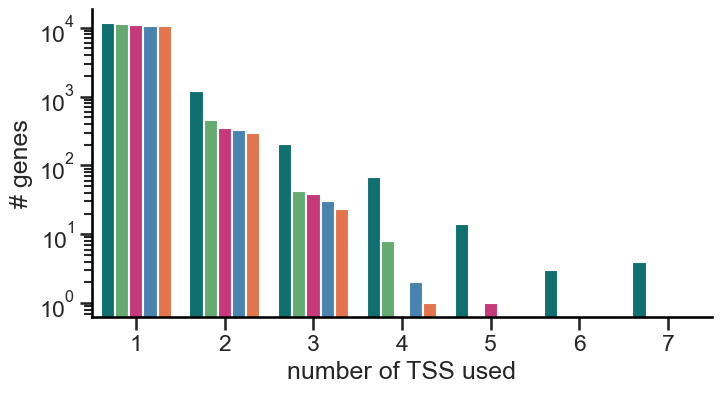

In [119]:
import matplotlib.ticker as ticker

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts['prom'], y=sumcounts['count'],hue=sumcounts['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'])
sns.despine()
plt.yscale('log',)
plt.legend([],frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')

plt.savefig('figures/fig4e_boxplot_promusage.pdf',bbox_inches='tight')
plt.show()

In [ ]:
# Prepare data for barplot of shared TSS usage

results_out = collections.defaultdict(lambda: collections.defaultdict(collections.Counter ))

for x in range(1, 12):
    list_prom = venn_diagram[venn_diagram['prom'] == x]
    a = set(list(list_prom[(list_prom['Lin'] == 'ESC') ] ['gene'].unique()))
    c = set(list(list_prom[(list_prom['Lin'] == 'ECT') | (list_prom['Lin'] == 'END') | (list_prom['Lin'] == 'MES') ] ['gene'].unique()))
    ESC_unique = len(a)-len(a.intersection(c))
    DIFF_unique = len(c)-len(a.intersection(c))
    intersect = len(a.intersection(c))
    
    results_out[x]['ESCs'] = ESC_unique
    results_out[x]['DIFF'] = DIFF_unique
    results_out[x]['intersect'] = intersect

TSS_stacked = pd.DataFrame(results_out).T

In [ ]:
TSS_stacked[['intersect','ESCs','DIFF']][0:1].plot.bar(stacked=True,figsize=(1.35,5),fontsize = 20,width=0.90, color = ['turquoise','teal','lightgrey'])
#plt.yscale('log')
#sns.despine()
plt.legend([],frameon=False)
plt.xticks(rotation=0, size = 26)
plt.yticks(size = 26)

plt.savefig('figures/fig4f_left_boxplot_shared_prom_usage.pdf',bbox_inches='tight')
plt.show()

In [ ]:
ax = TSS_stacked[['intersect','ESCs','DIFF']][1:6].plot.bar(stacked=True,figsize=(5,5),fontsize = 20,width=0.90, color = ['turquoise','teal','lightgrey'])
#plt.yscale('log')
#sns.despine()
plt.legend([],frameon=False)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.xticks(rotation=0, size = 26)
plt.yticks(size = 26)

plt.savefig('figures/fig4f_right_boxplot_shared_prom_usage.pdf',bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib_venn import venn3, venn3_circles

A = multiprom
B = difK4
C = onlydifRNA



fig,ax = plt.subplots(figsize = (5,5))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = ['grey',Green,Orange],
      set_labels = ['multiple TSS','dif. H3K4me3','dif. RNA'],
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

plt.savefig('figures/fig4g_venn_K4_RNA_diff_all.pdf',bbox_inches='tight')
plt.show()

In [ ]:
#prepare data to plot Vulcano plots for TSS differential usage

k4data['K4_plot_state']=0
k4data.loc[((k4data['K4_state_max_pos_prom_per_gene']>1)&(k4data['K4_prom_p']>2.3)&((k4data['K4_prom_fold']>1)|(k4data['K4_prom_fold']<-1))),'K4_plot_state']=1

k4data['RNA_plot_state']=0
k4data.loc[((k4data['RNA_prom_p']>2.3)&((k4data['RNA_prom_fold']>1)|(k4data['RNA_prom_fold']<-1))),'RNA_plot_state']=1

k4data['RNA_plot_state2']=0
k4data.loc[((k4data['K4_state_max_pos_prom_per_gene']>1)&(k4data['RNA_prom_p']>2.3)&((k4data['RNA_prom_fold']>1)|(k4data['RNA_prom_fold']<-1))),'RNA_plot_state2']=1



In [ ]:


sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

fig,ax=plt.subplots(figsize = (4,4))
g=sns.scatterplot(data=k4data[((k4data['K4_state_max_pos_prom_per_gene']>1)&(k4data['Lin']!='B'))].drop_duplicates(subset=['name','Lin'], keep='first'),legend=False, linewidth=0,s=30,x='K4_prom_fold', y='K4_prom_p', hue='K4_plot_state', alpha=0.5, palette=['Grey',Green],rasterized=True)
g.set_xlim(-5, 5)
plt.axvline(x=-1, ls='--', c='black')
plt.axvline(x=1, ls='--', c='black')
plt.axhline(y=2.3, ls='--', c='black')
sns.despine()
plt.savefig('figures/figS4g_H3K4me3_prom_ESC_fold_p.svg', dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
fig,ax=plt.subplots(figsize = (4,4))
g=sns.scatterplot(data=k4data[((k4data['K4_state_max_pos_prom_per_gene']>1)&(k4data['Lin']!='B'))].drop_duplicates(subset=['name','Lin'], keep='first'), legend=False, linewidth=0, s=30,x='RNA_prom_fold', y='RNA_prom_p', hue='RNA_plot_state', alpha=0.5, palette=['Grey',Orange],rasterized=True)
#g.set_xlim(-10, 100)
#g.set_ylim(-.2, 6)
plt.axvline(x=-1, ls='--', c='black')
plt.axvline(x=1, ls='--', c='black')
plt.axhline(y=2.3, ls='--', c='black')
sns.despine()
plt.savefig('figures/figS4g_20250701_RNA_prom_ESC_fold_p.svg', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
k4data2=k4data.copy()

In [ ]:
#export tables for later usage, first one is used to count on only the used TSS
final[final['name'].isin(prom_used_final['name'])].to_csv('output/20240114_mouse_selected_TSS_v2.bed',header=None, index=None, sep="\t")
final[final['biotype']=='protein_coding'].to_csv('output/20240114_mouse_all_protcode_TSS_v2.bed',header=None, index=None, sep="\t")
final2[((final2['biotype']=='protein_coding')&(final2['prom_type']=='main_an'))].drop_duplicates(subset=['name'], keep='first').to_csv('output/20240115_mouse_main_ano_TSS_v2.bed',header=None, index=None, sep="\t")

K4scdata[prom_used_final['name']].to_csv('output/20240114_H3K4me3_sc_selected_v2.csv',header=True, index=True, sep="\t")
K27scdata[prom_used_final['name']].to_csv('output/20240114_H3K27me3_sc_selected_v2.csv',header=True, index=True, sep="\t")
K4scdata[prom_used_dif_genes].to_csv('output/20240114_H3K4me3_sc_selected_dyn_TSS_v2.csv',header=True, index=True, sep="\t")
K27scdata[prom_used_dif_genes].to_csv('output/20240114_H3K27me3_sc_selected_dyn_TSS_v2.csv',header=True, index=True, sep="\t")
RNAscdatadown.loc[prom_used_dif_genes].to_csv('output/20240114_RNA_sc_selected_dyn_TSS_v2.csv',header=True, index=True, sep="\t")

#free up space
del RNAscdatadown, K27scdata, K4scdata

In [ ]:
#prepare tables to analyse genes that are determined to use a different main TSS from their first one

reannotated_genes_new=k4data.loc[k4data['name'].isin(prom_used_final.loc[prom_used_final['prom_type']=='other','name']),['gene','name','Lin','rep','prom_type','K4_sum','K27_sum','RNA_gene_sum','RNA_sum']]
reannotated_genes_new.columns=['gene','name_new','Lin','rep','prom_type_new','K4_new','K27_new','RNA_gene_new','RNA_new']
reannotated_genes_main=k4data.loc[((k4data['gene'].isin(reannotated_genes_new['gene']))&(k4data['prom_type']=='main_an')),['gene','name','Lin','rep','prom_type','K4_sum','K27_sum','RNA_gene_sum','RNA_sum']]
reannotated_genes_main.columns=['gene','name_main','Lin','rep','prom_type_main','K4_main','K27_main','RNA_gene_main','RNA_main']

reannotated_genes=reannotated_genes_new.merge(reannotated_genes_main, how='left', left_on=['gene','rep','Lin'], right_on=['gene','rep','Lin'])

agg_functions = {'K4_new': 'mean','K27_new': 'mean','RNA_gene_new': 'mean','K4_main': 'mean','K27_main': 'mean','RNA_gene_main': 'mean','RNA_main': 'mean','RNA_new': 'mean'}
reannotated_genes_plot=reannotated_genes.groupby(['gene','Lin']).aggregate(agg_functions)
reannotated_genes_plot=reannotated_genes_plot.reset_index()
reannotated_genes_plot['RNA_gene_log2']=np.log2(reannotated_genes_plot['RNA_gene_main']+1)
reannotated_genes_plot['K4_main_log2']=np.log2(reannotated_genes_plot['K4_main']+1)
reannotated_genes_plot['K4_new_log2']=np.log2(reannotated_genes_plot['K4_new']+1)
reannotated_genes_plot['K27_main_log2']=np.log2(reannotated_genes_plot['K27_main']+1)
reannotated_genes_plot['K27_new_log2']=np.log2(reannotated_genes_plot['K27_new']+1)


In [ ]:
scipy.stats.spearmanr(reannotated_genes_plot['K4_main_log2'], reannotated_genes_plot['RNA_gene_log2'])[0]

In [ ]:
ax = plt.figure(figsize=(6, 6))
ax=sns.scatterplot(data=reannotated_genes_plot, x=reannotated_genes_plot['K4_main_log2']-np.log2(cellnumber), y=reannotated_genes_plot['RNA_gene_log2']-np.log2(cellnumber),s= 20, color='grey')
ax.set_ylim(-9,6)
ax.set_xlim(-9,0)
plt.savefig('figures/figS4j_gene_reannotation_main_K4_vs_RNA.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.savefig('figures/figS4j_gene_reannotation_main_K4_vs_RNA.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

In [ ]:
scipy.stats.spearmanr(reannotated_genes_plot['K4_new_log2'], reannotated_genes_plot['RNA_gene_log2'])[0]

In [ ]:
ax = plt.figure(figsize=(6, 6))
ax=sns.scatterplot(data=reannotated_genes_plot, x=reannotated_genes_plot['K4_new_log2']-np.log2(cellnumber), y=reannotated_genes_plot['RNA_gene_log2']-np.log2(cellnumber),s= 20, color='black')

ax.set_ylim(-9,6)
ax.set_xlim(-9,0)
plt.savefig('figures/figS4j_gene_reannotation_new_K4_vs_RNA.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.savefig('figures/figS4j_gene_reannotation_new_K4_vs_RNA.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

In [ ]:



sns.set_context("talk", font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
 'ytick.left': True, 'axes.edgecolor': 'black'})

fig, axes = plt.subplots(1, 3, figsize=(12, 6), gridspec_kw={'hspace': 0 ,'width_ratios':(1,1,1)})
#plt.figure(figsize=(40,200))
axes = axes.flatten()
#fig.tight_layout(pad=0)


tmp2=reannotated_genes_plot.pivot(index='gene', columns='Lin', values='RNA_gene_new').sum(axis=1).sort_values(ascending=False)

k4vmax=(pd.concat([reannotated_genes_plot['K4_new'],(reannotated_genes_plot['K4_main'])])/cellnumber).quantile(q=0.95)
k27vmax=(pd.concat([reannotated_genes_plot['RNA_new'],(reannotated_genes_plot['RNA_main'])])/cellnumber).quantile(q=0.95)
RNAvmax=(reannotated_genes_plot['RNA_gene_log2']-np.log2(cellnumber)).quantile(q=1)



tmp=reannotated_genes_plot.pivot(index='gene', columns='Lin', values='RNA_gene_log2')
tmp=tmp[['ESC','ECT','MES','END']]
order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(tmp))
tmp=tmp.iloc[order]
sns.heatmap(tmp-np.log2(cellnumber), ax=axes[2], cmap=oranges_r, cbar=True, vmin=-np.log2(cellnumber), vmax=RNAvmax)
axes[2].tick_params(labelleft=False, left=False)
axes[2].tick_params(axis='x', rotation=90)
axes[2].set(xlabel='',
       ylabel='',
       title='RNA_gene')

tmp=reannotated_genes_plot.pivot(index='gene', columns='Lin', values='K4_new')
tmp=tmp[['ESC','ECT','MES','END']]

#order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(tmp))
tmp=tmp.iloc[order]

sns.heatmap(tmp/cellnumber, ax=axes[1], cmap=greens_r, cbar=True, vmin=0, vmax=k4vmax)
axes[1].tick_params(labelleft=False, left=False)
axes[1].tick_params(axis='x', rotation=90)
axes[1].set(xlabel='',
       ylabel='',
       title='K4_sel')


tmp=reannotated_genes_plot.pivot(index='gene', columns='Lin', values='K4_main')
tmp=tmp[['ESC','ECT','MES','END']]
tmp=tmp.iloc[order]
sns.heatmap(tmp/cellnumber, ax=axes[0], cmap=greens_r, cbar=True, vmin=0, vmax=k4vmax)
axes[0].tick_params(axis='x', rotation=90)
axes[0].set(xlabel='',
       ylabel='',
       title='K4_main')




plt.savefig('figures/figS4k_gene_reannotation_heatmap.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.savefig('figures/figS4k_gene_reannotation_heatmap.png', dpi=300, format='png', bbox_inches='tight')
plt.show()



In [123]:
#use genome wide single cell count data to prepare genome coverage elbow plots, genome_wide_counts.csv is a genome wide 50kb bin counttable after mergeing all bam files
whole_g_counts=pd.read_csv("input/genome_wide_counts.csv", sep = ',', header = 0 ,index_col=0, low_memory=True)
whole_g_counts=whole_g_counts[1:]

K4ESC=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['celltype']=='mESCs')&(adata.obs['mark']=='H3K4me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)
K4ECT=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['lineage']=='Ectoderm')&(adata.obs['mark']=='H3K4me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)
K4END=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['lineage']=='Endoderm')&(adata.obs['mark']=='H3K4me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)
K4MES=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['lineage']=='Mesoderm')&(adata.obs['mark']=='H3K4me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)

K27ESC=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['celltype']=='mESCs')&(adata.obs['mark']=='H3K27me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)
K27ECT=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['lineage']=='Ectoderm')&(adata.obs['mark']=='H3K27me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)
K27END=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['lineage']=='Endoderm')&(adata.obs['mark']=='H3K27me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)
K27MES=whole_g_counts.loc[:,whole_g_counts.columns.isin(adata[((adata.obs['lineage']=='Mesoderm')&(adata.obs['mark']=='H3K27me3'))].obs.index)].sum(axis=1).sort_values().cumsum().reset_index(drop=True)

del whole_g_counts

K4ESC=K4ESC/K4ESC.max()
K4ECT=K4ECT/K4ECT.max()
K4END=K4END/K4END.max()
K4MES=K4MES/K4MES.max()

K27ESC=K27ESC/K27ESC.max()
K27ECT=K27ECT/K27ECT.max()
K27END=K27END/K27END.max()
K27MES=K27MES/K27MES.max()

nromdata=pd.concat([K4ESC,K4ECT,K4END,K4MES,K27ESC,K27ECT,K27END,K27MES],axis=1)
nromdata.columns=['K4ESC','K4ECT','K4END','K4MES','K27ESC','K27ECT','K27END','K27MES']

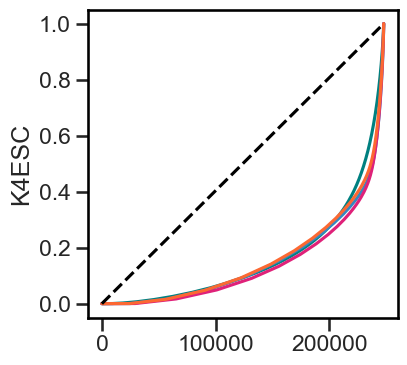

In [125]:
fig,ax=plt.subplots(figsize = (4,4))

sns.lineplot(data=nromdata['K4ESC'], color='teal')
sns.lineplot(data=nromdata['K4ECT'], color='#3787c0')
sns.lineplot(data=nromdata['K4MES'], color='#df2179')
sns.lineplot(data=nromdata['K4END'], color='#fc6832')

plt.plot([0, len(nromdata)], [0, 1], ls='--', c='black')


plt.savefig('figures/figS4f_H3K4me3_cumsum_norm.png', dpi=300, format='png', bbox_inches='tight')
plt.savefig('figures/figS4f_H3K4me3_cumsum_norm.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()

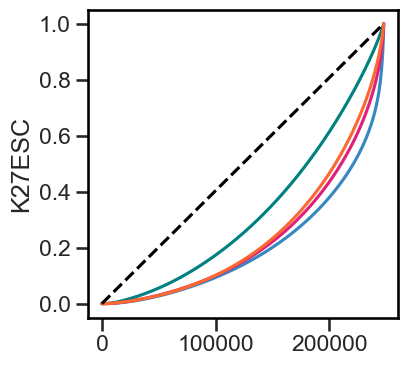

In [126]:
fig,ax=plt.subplots(figsize = (4,4))

sns.lineplot(data=nromdata['K27ESC'], color='teal')
sns.lineplot(data=nromdata['K27ECT'], color='#3787c0')
sns.lineplot(data=nromdata['K27MES'], color='#df2179')
sns.lineplot(data=nromdata['K27END'], color='#fc6832')

plt.plot([0, len(nromdata)], [0, 1], ls='--', c='black')


plt.savefig('figures/figS4f_H3K27me3_cumsum_norm.png', dpi=300, format='png', bbox_inches='tight')
plt.savefig('figures/figS4f_H3K27me3_cumsum_norm.pdf', dpi=300, format='pdf', bbox_inches='tight')
plt.show()